### Importing the dataset

In [1]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
api = KaggleApi()
api.authenticate()

if not os.path.exists("../datasets/Students Social Media Addiction.csv"):
    api.dataset_download_files(
        "zahranusratt/student-social-media-addiction-analysis-dataset",
        path="../datasets",
        unzip=True
    )
else:
    print("dataset already on local files")

csv_file = os.path.join("../datasets","Students Social Media Addiction.csv")
df = pd.read_csv(csv_file)

print("dataset ready to use")

dataset already on local files
dataset ready to use


### No prior clustering techniques knowledge 

PREPROCESSING BEFORE:  ==========
Age                               int64
Gender                              str
Academic_Level                      str
Country                             str
Avg_Daily_Usage_Hours           float64
Most_Used_Platform                  str
Affects_Academic_Performance        str
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status                 str
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object

PREPROCESSING AFTER:  ==========
Age                                    int64
Avg_Daily_Usage_Hours                float64
Sleep_Hours_Per_Night                float64
Mental_Health_Score                    int64
Conflicts_Over_Social_Media            int64
Addicted_Score                         int64
Gender_code                             int8
Academic_Level_code                     int8
Country_code                            int8
Most_Used_Platform_code          

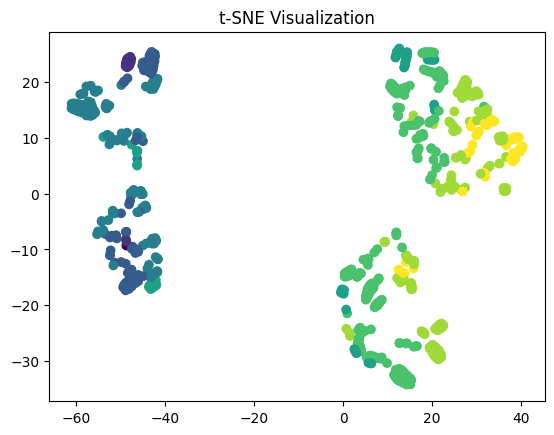

In [2]:
engineered_df = df.drop(columns=['Student_ID'])
labels = df['Addicted_Score']

print('PREPROCESSING BEFORE: ','='*10)
print(engineered_df.dtypes)

columns_to_drop = set()
for column in engineered_df.columns:
    if engineered_df[column].dtype == 'str':
        # print(column)
        engineered_df[column + '_code'] = df[column].astype('category').cat.codes
        columns_to_drop.add(column)

engineered_df = engineered_df.drop(columns=columns_to_drop)
print('\nPREPROCESSING AFTER: ','='*10)
print(engineered_df.dtypes)

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt


scaler = StandardScaler()
X_scaled = scaler.fit_transform(engineered_df.to_numpy())


tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=10000, init='pca')
X_embedded = tsne.fit_transform(X_scaled)

# 3. Visualize results
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels)
plt.title("t-SNE Visualization")
plt.show()   

The clusters are plotted using wrong data engineering techniques. The customized attempt to preprocess the data was the culprit, **as it attributes categorical features values numerical values without normalizing it later**, which leads to a totally biased and not informative or helpful plot.

### Early normalization attempt

Age                               int64
Gender                              str
Academic_Level                      str
Country                             str
Avg_Daily_Usage_Hours           float64
Most_Used_Platform                  str
Affects_Academic_Performance        str
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status                 str
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object
Age                                      int64
Avg_Daily_Usage_Hours                  float64
Sleep_Hours_Per_Night                  float64
Mental_Health_Score                      int64
Conflicts_Over_Social_Media              int64
                                        ...   
Most_Used_Platform_WhatsApp               bool
Most_Used_Platform_YouTube                bool
Affects_Academic_Performance_Yes          bool
Relationship_Status_In Relationship       bool
Relationship_Status_Single          

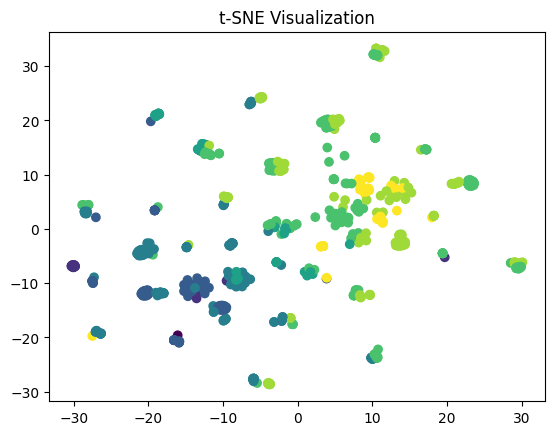

In [3]:
engineered_df = df.drop(columns=['Student_ID'])
print(engineered_df.dtypes)
engineered_df = pd.get_dummies(engineered_df, drop_first=True)
print(engineered_df.dtypes)
labels = df['Addicted_Score']

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(engineered_df.to_numpy())

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=10000, init='pca')
X_embedded = tsne.fit_transform(X_scaled)

plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels)
plt.title("t-SNE Visualization")
plt.show()   

The clusters seem to be less spoiled now, but the plot is stil isn't helpful at all, there are no clear clusters or even a decent labelling. The hyperparameters are also too extreme, *max_iter* specially.

### Early attempt to use binning as a way to create clusters

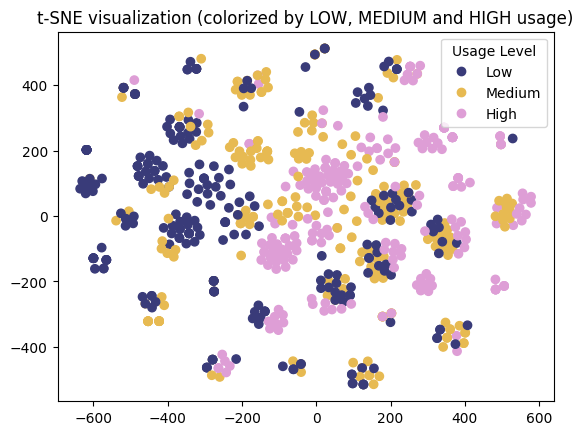

sleep_bin,Low,Medium,High
usage_bin,,,
Low,0.015444,0.223938,0.760618
Medium,0.290749,0.581498,0.127753
High,0.757991,0.242009,0.000000


In [4]:
engineered_df = df.drop(columns=['Student_ID'])
# print(engineered_df.dtypes)
engineered_df['usage_bin'] = pd.qcut(
    engineered_df['Avg_Daily_Usage_Hours'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
engineered_df['sleep_bin'] = pd.qcut(
    engineered_df['Sleep_Hours_Per_Night'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
usage_cat = engineered_df['usage_bin'].astype('category')
labels = usage_cat.cat.codes
label_names = list(usage_cat.cat.categories)

TSNE_optimized_engineered_df = engineered_df.drop(columns=['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'usage_bin', 'sleep_bin'])
TSNE_optimized_engineered_df = pd.get_dummies(TSNE_optimized_engineered_df, drop_first=True)
# print(TSNE_optimized_engineered_df.dtypes)

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(TSNE_optimized_engineered_df.to_numpy())

tsne = TSNE(n_components=2, perplexity=50, learning_rate=200, max_iter=3500, init='pca')
X_embedded = tsne.fit_transform(X_scaled)

scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels, cmap='tab20b')
handles, _ = scatter.legend_elements()
plt.legend(
    handles,
    label_names,
    title="Usage Level"
)
plt.title("t-SNE visualization (colorized by LOW, MEDIUM and HIGH usage)")
plt.show()
pd.crosstab(engineered_df['usage_bin'], engineered_df['sleep_bin'], normalize='index')


BEFORE ONE-HOT ENCODING: 
['Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media', 'Addicted_Score', 'usage_bin', 'sleep_bin']
BINNED AVG_USAGE AND AVG_SLEEP_HOURS: 
usage_bin
Low       259
Medium    227
High      219
Name: count, dtype: int64
sleep_bin
Medium    243
Low       236
High      226
Name: count, dtype: int64
AFTER ONE-HOT ENCODING: 
['Age', 'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score', 'Gender_Female', 'Gender_Male', 'Academic_Level_Graduate', 'Academic_Level_High School', 'Academic_Level_Undergraduate', 'Country_Afghanistan', 'Country_Albania', 'Country_Andorra', 'Country_Argentina', 'Country_Armenia', 'Country_Australia', 'Country_Austria', 'Country_Azerbaijan', 'Country_Bahamas', 'Country_Bahrain', 'Country_Bangladesh', 'Country_Belarus', 'Country_Belgium', 'Country_Bhutan', 'C

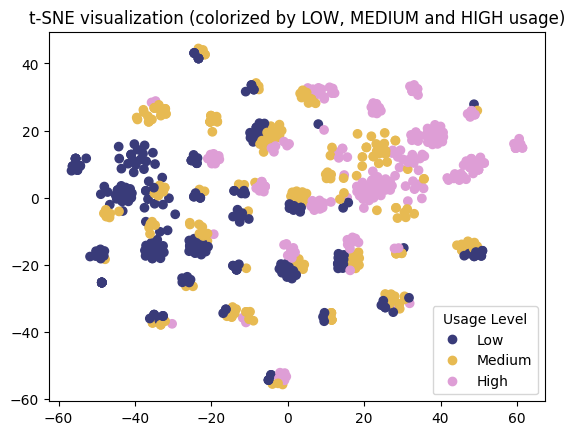

sleep_bin,Low,Medium,High
usage_bin,,,
Low,0.015444,0.223938,0.760618
Medium,0.290749,0.581498,0.127753
High,0.757991,0.242009,0.000000


In [5]:
engineered_df = df.drop(columns=['Student_ID'])
engineered_df['usage_bin'] = pd.qcut(
    engineered_df['Avg_Daily_Usage_Hours'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
engineered_df['sleep_bin'] = pd.qcut(
    engineered_df['Sleep_Hours_Per_Night'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

usage_cat = engineered_df['usage_bin'].astype('category')
labels = usage_cat.cat.codes
label_names = list(usage_cat.cat.categories)
print('BEFORE ONE-HOT ENCODING: ')
print(list(engineered_df.columns))

print('BINNED AVG_USAGE AND AVG_SLEEP_HOURS: ')
print(engineered_df['usage_bin'].value_counts())
print(engineered_df['sleep_bin'].value_counts())

TSNE_optimized_engineered_df = engineered_df.drop(columns=['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night'])
TSNE_optimized_engineered_df = pd.get_dummies(TSNE_optimized_engineered_df)

print('AFTER ONE-HOT ENCODING: ')
print(list(TSNE_optimized_engineered_df.columns))
print(TSNE_optimized_engineered_df.head(10))



from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(TSNE_optimized_engineered_df.to_numpy())

tsne = TSNE(n_components=2, perplexity=35, learning_rate='auto', max_iter=3000, n_iter_without_progress=3500, init='pca')
X_embedded = tsne.fit_transform(X_scaled)

scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], cmap='tab20b', c=labels)
plt.title("t-SNE visualization (colorized by LOW, MEDIUM and HIGH usage)")
handles, _ = scatter.legend_elements()
plt.legend(
    handles,
    label_names,
    title="Usage Level"
)
plt.show()
pd.crosstab(engineered_df['usage_bin'], engineered_df['sleep_bin'], normalize='index')

BEFORE ONE-HOT ENCODING: 
['Gender', 'Academic_Level', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media', 'Addicted_Score', 'usage_bin', 'sleep_bin']
BINNED AVG_USAGE AND AVG_SLEEP_HOURS: 
usage_bin
Low       259
Medium    227
High      219
Name: count, dtype: int64
sleep_bin
Medium    243
Low       236
High      226
Name: count, dtype: int64
AFTER ONE-HOT ENCODING: 
['Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score', 'Gender_Female', 'Gender_Male', 'Academic_Level_Graduate', 'Academic_Level_High School', 'Academic_Level_Undergraduate', 'Most_Used_Platform_Facebook', 'Most_Used_Platform_Instagram', 'Most_Used_Platform_KakaoTalk', 'Most_Used_Platform_LINE', 'Most_Used_Platform_LinkedIn', 'Most_Used_Platform_Snapchat', 'Most_Used_Platform_TikTok', 'Most_Used_Platform_Twitter', 'Most_Used_Platform_VKontakte', 'Most_Used_Platform_WeChat', 'M

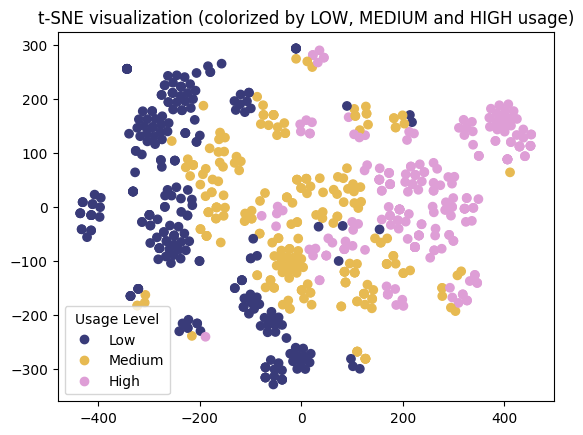

sleep_bin,Low,Medium,High
usage_bin,,,
Low,0.015444,0.223938,0.760618
Medium,0.290749,0.581498,0.127753
High,0.757991,0.242009,0.000000


In [6]:
engineered_df = df.drop(columns=['Student_ID', 'Country', 'Age'])
engineered_df['usage_bin'] = pd.qcut(
    engineered_df['Avg_Daily_Usage_Hours'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
engineered_df['sleep_bin'] = pd.qcut(
    engineered_df['Sleep_Hours_Per_Night'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

usage_cat = engineered_df['usage_bin'].astype('category')
labels = usage_cat.cat.codes
label_names = list(usage_cat.cat.categories)
print('BEFORE ONE-HOT ENCODING: ')
print(list(engineered_df.columns))

print('BINNED AVG_USAGE AND AVG_SLEEP_HOURS: ')
print(engineered_df['usage_bin'].value_counts())
print(engineered_df['sleep_bin'].value_counts())

TSNE_optimized_engineered_df = engineered_df.drop(columns=['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night'])
TSNE_optimized_engineered_df = pd.get_dummies(TSNE_optimized_engineered_df)

print('AFTER ONE-HOT ENCODING: ')
print(list(TSNE_optimized_engineered_df.columns))
print(TSNE_optimized_engineered_df.head(10))



from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(TSNE_optimized_engineered_df.to_numpy())

tsne = TSNE(n_components=2, perplexity=50, learning_rate='auto', max_iter=3000, n_iter_without_progress=300, init='pca')
X_embedded = tsne.fit_transform(X_scaled)

# 3. Visualize results
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], cmap='tab20b', c=labels)
plt.title("t-SNE visualization (colorized by LOW, MEDIUM and HIGH usage)")
handles, _ = scatter.legend_elements()
plt.legend(
    handles,
    label_names,
    title="Usage Level"
)
plt.show()
pd.crosstab(engineered_df['usage_bin'], engineered_df['sleep_bin'], normalize='index')

BEFORE ONE-HOT ENCODING: 
['Gender', 'Academic_Level', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media', 'Addicted_Score', 'usage_bin', 'sleep_bin']
BINNED AVG_USAGE AND AVG_SLEEP_HOURS: 
usage_bin
Low       259
Medium    227
High      219
Name: count, dtype: int64
sleep_bin
Medium    243
Low       236
High      226
Name: count, dtype: int64
AFTER ONE-HOT ENCODING: 
['Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score', 'Gender_Female', 'Gender_Male', 'Academic_Level_Graduate', 'Academic_Level_High School', 'Academic_Level_Undergraduate', 'Most_Used_Platform_Facebook', 'Most_Used_Platform_Instagram', 'Most_Used_Platform_KakaoTalk', 'Most_Used_Platform_LINE', 'Most_Used_Platform_LinkedIn', 'Most_Used_Platform_Snapchat', 'Most_Used_Platform_TikTok', 'Most_Used_Platform_Twitter', 'Most_Used_Platform_VKontakte', 'Most_Used_Platform_WeChat', 'M

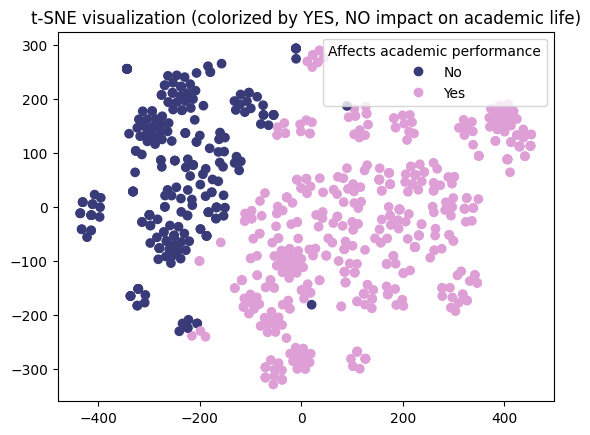

sleep_bin,Low,Medium,High
usage_bin,,,
Low,0.015444,0.223938,0.760618
Medium,0.290749,0.581498,0.127753
High,0.757991,0.242009,0.000000


In [7]:
engineered_df = df.drop(columns=['Student_ID', 'Country', 'Age'])
engineered_df['usage_bin'] = pd.qcut(
    engineered_df['Avg_Daily_Usage_Hours'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
engineered_df['sleep_bin'] = pd.qcut(
    engineered_df['Sleep_Hours_Per_Night'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

usage_cat = engineered_df['Affects_Academic_Performance'].astype('category')
labels = usage_cat.cat.codes
label_names = list(usage_cat.cat.categories)
print('BEFORE ONE-HOT ENCODING: ')
print(list(engineered_df.columns))

print('BINNED AVG_USAGE AND AVG_SLEEP_HOURS: ')
print(engineered_df['usage_bin'].value_counts())
print(engineered_df['sleep_bin'].value_counts())

TSNE_optimized_engineered_df = engineered_df.drop(columns=['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night'])
TSNE_optimized_engineered_df = pd.get_dummies(TSNE_optimized_engineered_df)

print('AFTER ONE-HOT ENCODING: ')
print(list(TSNE_optimized_engineered_df.columns))
print(TSNE_optimized_engineered_df.head(10))



from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(TSNE_optimized_engineered_df.to_numpy())

tsne = TSNE(n_components=2, perplexity=50, learning_rate='auto', max_iter=3000, n_iter_without_progress=300, init='pca')
X_embedded = tsne.fit_transform(X_scaled)

# 3. Visualize results
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], cmap='tab20b', c=labels)
plt.title("t-SNE visualization (colorized by YES, NO impact on academic life)")
handles, _ = scatter.legend_elements()
plt.legend(
    handles,
    label_names,
    title="Affects academic performance"
)
plt.show()
pd.crosstab(engineered_df['usage_bin'], engineered_df['sleep_bin'], normalize='index')

BEFORE ONE-HOT ENCODING: 
['Gender', 'Academic_Level', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media', 'Addicted_Score', 'usage_bin', 'sleep_bin']
BINNED AVG_USAGE AND AVG_SLEEP_HOURS: 
usage_bin
Low       259
Medium    227
High      219
Name: count, dtype: int64
sleep_bin
Medium    243
Low       236
High      226
Name: count, dtype: int64
AFTER ONE-HOT ENCODING: 
['Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score', 'Gender_Female', 'Gender_Male', 'Academic_Level_Graduate', 'Academic_Level_High School', 'Academic_Level_Undergraduate', 'Most_Used_Platform_Facebook', 'Most_Used_Platform_Instagram', 'Most_Used_Platform_KakaoTalk', 'Most_Used_Platform_LINE', 'Most_Used_Platform_LinkedIn', 'Most_Used_Platform_Snapchat', 'Most_Used_Platform_TikTok', 'Most_Used_Platform_Twitter', 'Most_Used_Platform_VKontakte', 'Most_Used_Platform_WeChat', 'M

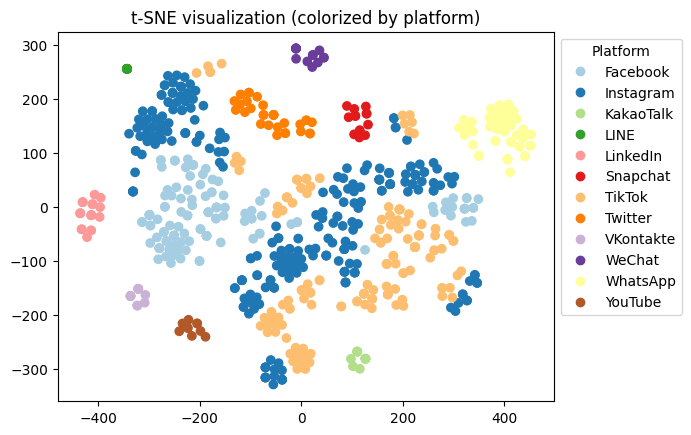

sleep_bin,Low,Medium,High
usage_bin,,,
Low,0.015444,0.223938,0.760618
Medium,0.290749,0.581498,0.127753
High,0.757991,0.242009,0.000000


In [8]:
engineered_df = df.drop(columns=['Student_ID', 'Country', 'Age'])
engineered_df['usage_bin'] = pd.qcut(
    engineered_df['Avg_Daily_Usage_Hours'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
engineered_df['sleep_bin'] = pd.qcut(
    engineered_df['Sleep_Hours_Per_Night'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

usage_cat = engineered_df['Most_Used_Platform'].astype('category')
labels = usage_cat.cat.codes
label_names = list(usage_cat.cat.categories)
print('BEFORE ONE-HOT ENCODING: ')
print(list(engineered_df.columns))

print('BINNED AVG_USAGE AND AVG_SLEEP_HOURS: ')
print(engineered_df['usage_bin'].value_counts())
print(engineered_df['sleep_bin'].value_counts())

TSNE_optimized_engineered_df = engineered_df.drop(columns=['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night'])
TSNE_optimized_engineered_df = pd.get_dummies(TSNE_optimized_engineered_df)

print('AFTER ONE-HOT ENCODING: ')
print(list(TSNE_optimized_engineered_df.columns))
print(TSNE_optimized_engineered_df.head(5))

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
scaler = StandardScaler()
X_scaled = scaler.fit_transform(TSNE_optimized_engineered_df.to_numpy())

tsne = TSNE(n_components=2, perplexity=50, learning_rate='auto', max_iter=3000, n_iter_without_progress=300, init='pca')
X_embedded = tsne.fit_transform(X_scaled)

scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], cmap='Paired', c=labels)
plt.title("t-SNE visualization (colorized by platform)")
handles, _ = scatter.legend_elements()
plt.legend(
    handles,
    label_names,
    title="Platform",
    loc="upper left",
    bbox_to_anchor=(1, 1)
)
plt.show()
pd.crosstab(engineered_df['usage_bin'], engineered_df['sleep_bin'], normalize='index')

The clusters are visible now, but there are more optmizations that can be done.

### Correctly normalizing the data and using better visualizations tools

Scaled dataframe:
         Age  Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  \
0 -1.186915               0.223857              -0.327638   
1  0.958662              -2.243309               0.560423   
2 -0.471723               0.860545              -1.659730   
3 -1.902108              -1.527035               0.116393   
4  0.243470              -0.333245              -0.771668   

   Mental_Health_Score  Conflicts_Over_Social_Media  Addicted_Score  \
0            -0.205520                     0.157063        0.985550   
1             1.605628                    -2.976790       -2.166958   
2            -1.111095                     1.201681        1.616052   
3             0.700054                    -1.932172       -1.536456   
4            -0.205520                    -0.887554        0.355048   

   Gender_Female  Gender_Male  Academic_Level_Graduate  \
0       0.998583    -0.998583                -0.924804   
1      -1.001419     1.001419                 1.081310   
2       0.998

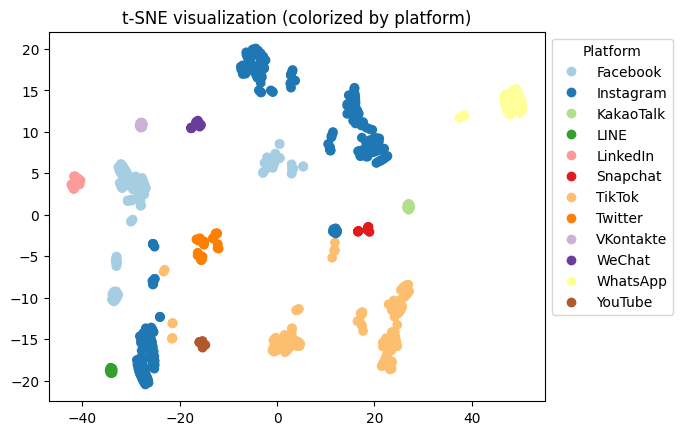

In [9]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


engineered_df = df.drop(columns=['Student_ID', 'Country', 'Relationship_Status'])
usage_cat = engineered_df['Most_Used_Platform'].astype('category')
labels = usage_cat.cat.codes
label_names = list(usage_cat.cat.categories)

TSNE_optimized_engineered_df = engineered_df
TSNE_optimized_engineered_df = pd.get_dummies(TSNE_optimized_engineered_df)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(TSNE_optimized_engineered_df)
tsne = TSNE(n_components=2, perplexity=35, learning_rate='auto', max_iter=1500, n_iter_without_progress=300, init='pca')
X_embedded = tsne.fit_transform(X_scaled)
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], cmap='Paired', c=labels)

print("Scaled dataframe:\n", pd.DataFrame(X_scaled, columns=TSNE_optimized_engineered_df.columns).head(5))
X_embedded = tsne.fit_transform(X_scaled)
plt.title("t-SNE visualization (colorized by platform)")

handles, _ = scatter.legend_elements()
plt.legend(
    handles,
    label_names,
    title="Platform",
    loc="upper left",
    bbox_to_anchor=(1, 1)
)
plt.show()


Here is what I was looking for, dense and defined clusters that can provide insights from simplified hyperdimensional data.

### Using plotly for in-depth analysis

In [10]:
from sklearn.manifold import TSNE
import plotly.express as px
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


engineered_df = df.drop(columns=['Student_ID', 'Country', 'Relationship_Status'])
usage_cat = engineered_df['Most_Used_Platform'].astype('category')
labels = usage_cat.cat.codes
label_names = list(usage_cat.cat.categories)
TSNE_optimized_engineered_df = engineered_df#.drop(columns=['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night'])
TSNE_optimized_engineered_df = pd.get_dummies(TSNE_optimized_engineered_df)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(TSNE_optimized_engineered_df)

tsne = TSNE(n_components=2, perplexity=35, learning_rate='auto', max_iter=1500, n_iter_without_progress=300, init='pca')
projections = tsne.fit_transform(X_scaled)
fig = px.scatter(
    projections,
    x=0,
    y=1,
    color=engineered_df.Most_Used_Platform,
    labels={'color': 'Most_Used_Platform'},
    hover_data={
            'Avg_Daily_Usage_Hours': engineered_df.Avg_Daily_Usage_Hours,
            'Affects_Academic_Performance': engineered_df.Affects_Academic_Performance,
            'Sleep_Hours_Per_Night': engineered_df.Sleep_Hours_Per_Night,
            'Mental_Health_Score': engineered_df.Mental_Health_Score,
            'Addicted_Score': engineered_df.Addicted_Score
        },
    width=600, 
    height=400,
)
fig.show()


In [11]:
from sklearn.manifold import TSNE
import plotly.express as px
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


engineered_df = df.drop(columns=['Student_ID', 'Country', 'Relationship_Status'])
usage_cat = engineered_df['Most_Used_Platform'].astype('category')
labels = usage_cat.cat.codes
label_names = list(usage_cat.cat.categories)
TSNE_optimized_engineered_df = engineered_df#.drop(columns=['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night'])
TSNE_optimized_engineered_df = pd.get_dummies(TSNE_optimized_engineered_df)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(TSNE_optimized_engineered_df)

tsne = TSNE(n_components=3, perplexity=40, learning_rate='auto', max_iter=5000, n_iter_without_progress=300, init='pca')
projections = tsne.fit_transform(X_scaled)

fig = px.scatter_3d(
    projections,
    x=0,
    y=1,
    z=2,
    color=df.Most_Used_Platform,
    labels={'color': 'Most_Used_Platform'},
    hover_data={
        'Avg_Daily_Usage_Hours': engineered_df.Avg_Daily_Usage_Hours,
        'Affects_Academic_Performance': engineered_df.Affects_Academic_Performance,
        'Sleep_Hours_Per_Night': engineered_df.Sleep_Hours_Per_Night,
        'Mental_Health_Score': engineered_df.Mental_Health_Score,
        'Addicted_Score': engineered_df.Addicted_Score
    },
    width=800, 
    height=500,
)
fig.show()


### Key insights and considerations

[WIP]
- The t-SNE dimensionality reduction visualization shows that **some groupings appear to be associated with specific platforms.** Whatsapp for instance, has a very tight cluster that suggests very similar feature values, such as: average usage time, sleep patterns and addiction score. This indicates that users could potentially be subdivided into behavioral profiles for deeper analysis.

- The t-SNE also shows that platform does not appear to be the dominant factor, as it shows three distinct clusters (and two or three smaller ones) for Instagram users, which indicates behavioral differences, which goes from four to nine in addiction score.
- This technique is very tricky and needs orientation for beginners, to extract value and helpful insights
    - Perplexity seems to be the most important hyperparameter, as well as the number os iterations. A good plot should not use extreme values, as it can group data points that should not be that close together.
    - Super fun!